In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import warnings
warnings.filterwarnings('ignore')

os.makedirs('results', exist_ok=True)
print("TensorFlow:", tf.__version__)
print("All libraries loaded!")

TensorFlow: 2.20.0
All libraries loaded!


In [39]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/ai_project_synthetic_datasets-20260505T171228Z-3-001/ai_project_synthetic_datasets/part_3_nlp_sequence_modeling/customer_support_text_classification.csv'

df = pd.read_csv(path)
print("Dataset loaded!")
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
display(df.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded!

Shape: (1500, 6)

Columns: ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

First 3 rows:


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0


In [40]:
print("=" * 55)
print("DATASET UNDERSTANDING")
print("=" * 55)

print(f"\nTotal Records     : {df.shape[0]}")
print(f"Total Columns     : {df.shape[1]}")

print(f"\nTarget Column - sentiment_label:")
print(df['sentiment_label'].value_counts())

print(f"\nChannel Distribution:")
print(df['channel'].value_counts())

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nAverage word count per message : {df['word_count'].mean():.1f}")
print(f"Max word count                 : {df['word_count'].max()}")
print(f"Min word count                 : {df['word_count'].min()}")

print(f"\nSample text records:")
for i in range(3):
    print(f"\n[{i+1}] Label: {df['sentiment_label'].iloc[i]}")
    print(f"     Text : {df['customer_message'].iloc[i]}")

DATASET UNDERSTANDING

Total Records     : 1500
Total Columns     : 6

Target Column - sentiment_label:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Channel Distribution:
channel
email     326
social    314
phone     296
chat      290
app       274
Name: count, dtype: int64

Missing Values:
ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0
dtype: int64

Average word count per message : 12.7
Max word count                 : 26
Min word count                 : 7

Sample text records:

[1] Label: neutral
     Text : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

[2] Label: neutral
     Text : I need information about the payment process.

[3] Label: positive
     Text : The refund process was fast and convenient. I appreciate the quick response.


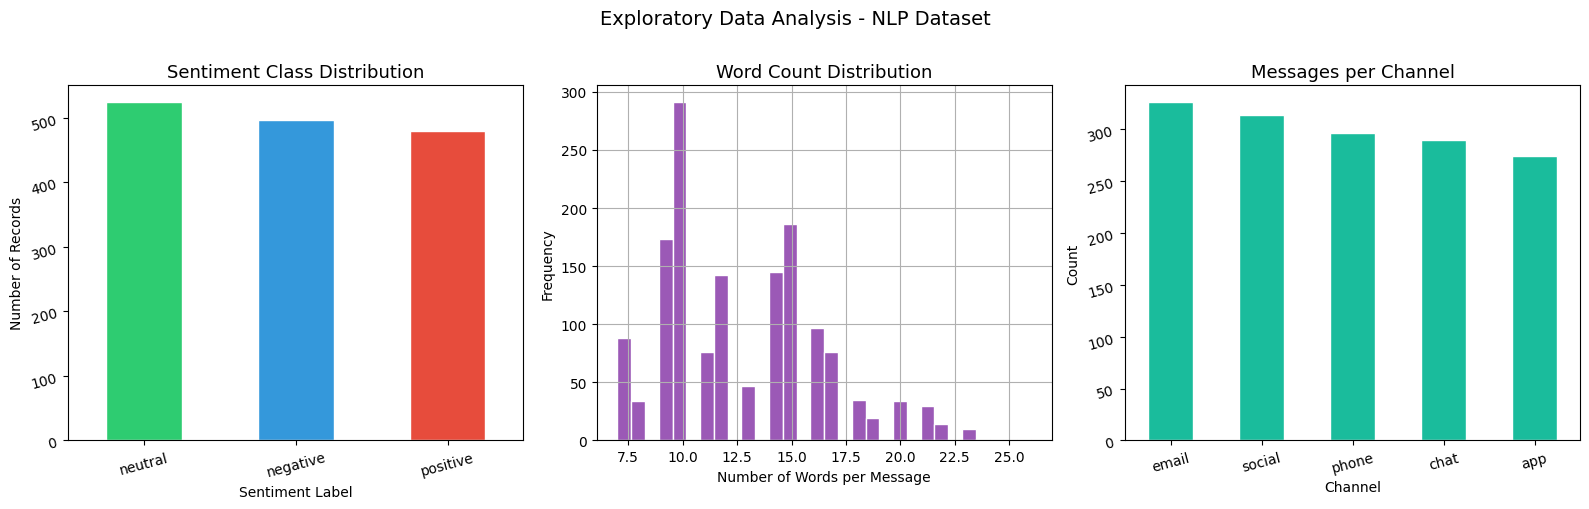

EDA plots saved!


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 - Class distribution
df['sentiment_label'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71','#3498db','#e74c3c'],
    edgecolor='white')
axes[0].set_title('Sentiment Class Distribution', fontsize=13)
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Number of Records')
axes[0].tick_params(rotation=15)

# Plot 2 - Word count distribution
df['word_count'].hist(bins=30, ax=axes[1], color='#9b59b6', edgecolor='white')
axes[1].set_title('Word Count Distribution', fontsize=13)
axes[1].set_xlabel('Number of Words per Message')
axes[1].set_ylabel('Frequency')

# Plot 3 - Channel wise distribution
df['channel'].value_counts().plot(
    kind='bar', ax=axes[2],
    color='#1abc9c', edgecolor='white')
axes[2].set_title('Messages per Channel', fontsize=13)
axes[2].set_xlabel('Channel')
axes[2].set_ylabel('Count')
axes[2].tick_params(rotation=15)

plt.suptitle('Exploratory Data Analysis - NLP Dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('results/eda_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print("EDA plots saved!")

In [42]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['customer_message'].apply(clean_text)

print("Text Preprocessing Applied:")
print("  - Converted to lowercase")
print("  - Removed all digits")
print("  - Removed punctuation marks")
print("  - Stripped extra whitespace")

print(f"\nBefore Cleaning:")
print(f"  {df['customer_message'].iloc[0]}")
print(f"\nAfter Cleaning:")
print(f"  {df['clean_text'].iloc[0]}")
print("\nPreprocessing complete!")

Text Preprocessing Applied:
  - Converted to lowercase
  - Removed all digits
  - Removed punctuation marks
  - Stripped extra whitespace

Before Cleaning:
  I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

After Cleaning:
  i need information about the payment process my ticket number is please respond as soon as possible

Preprocessing complete!


In [43]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment_label'])

print("Label Encoding:")
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {idx}")

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=7,
    stratify=y
)

print(f"\nTrain samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"\nTrain label distribution:")
print(pd.Series(y_train).value_counts())

Label Encoding:
  negative → 0
  neutral → 1
  positive → 2

Train samples : 1200
Test samples  : 300

Train label distribution:
label
1    419
0    398
2    383
Name: count, dtype: int64


In [44]:
# Method 1 - Bag of Words
bow = CountVectorizer(max_features=4000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)
print(f"Bag of Words matrix shape (train) : {X_train_bow.shape}")

# Method 2 - TF-IDF
tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"TF-IDF matrix shape (train)       : {X_train_tfidf.shape}")

print(f"\nTop 10 TF-IDF features:")
print(tfidf.get_feature_names_out()[:10].tolist())

print("""
Why must text be converted to vectors?
Neural networks and ML models only understand numbers.
Raw string text cannot be passed to any model directly.

Bag of Words: counts raw word frequency per document.
Simple but ignores how important or rare a word is.

TF-IDF: weights words by frequency AND uniqueness across
documents. Rare but meaningful words score higher than
common filler words like 'the', 'is', 'a'.
""")

Bag of Words matrix shape (train) : (1200, 180)
TF-IDF matrix shape (train)       : (1200, 572)

Top 10 TF-IDF features:
['about', 'about the', 'account', 'account details', 'account has', 'account is', 'account keeps', 'account request', 'activate', 'activate analytics']

Why must text be converted to vectors?
Neural networks and ML models only understand numbers.
Raw string text cannot be passed to any model directly.

Bag of Words: counts raw word frequency per document.
Simple but ignores how important or rare a word is.

TF-IDF: weights words by frequency AND uniqueness across
documents. Rare but meaningful words score higher than
common filler words like 'the', 'is', 'a'.



Naive Bayes Accuracy  : 100.00%
Linear SVM Accuracy   : 100.00%

Classification Report (Best Baseline - SVM):
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



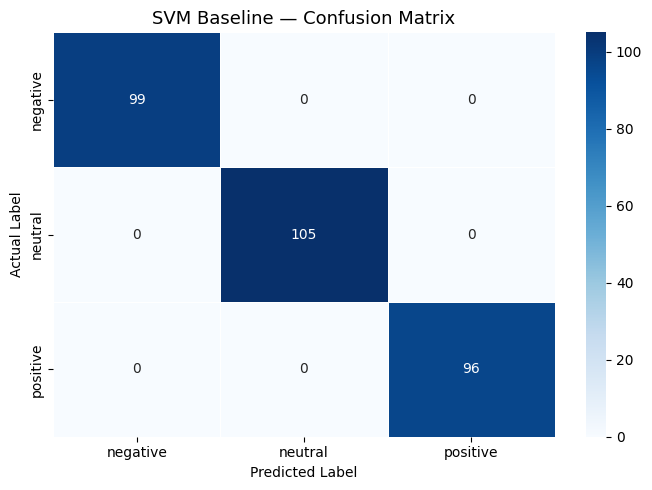

Baseline confusion matrix saved!


In [45]:
# Model 1 - Naive Bayes
nb = MultinomialNB(alpha=0.5)
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy  : {nb_acc*100:.2f}%")

# Model 2 - Linear SVM
svm = LinearSVC(max_iter=2000, random_state=42)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)
svm_acc = accuracy_score(y_test, y_pred_svm)
print(f"Linear SVM Accuracy   : {svm_acc*100:.2f}%")

print("\nClassification Report (Best Baseline - SVM):")
print(classification_report(
    y_test, y_pred_svm,
    target_names=le.classes_
))

# Confusion matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=0.5)
plt.title('SVM Baseline — Confusion Matrix', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('results/model_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()
print("Baseline confusion matrix saved!")

In [46]:
MAX_WORDS = 8000
MAX_LEN   = 40

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<UNK>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pre-padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='pre')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='pre')

num_classes = len(le.classes_)

print(f"Vocabulary size      : {len(tokenizer.word_index)}")
print(f"Padded train shape   : {X_train_pad.shape}")
print(f"Padded test shape    : {X_test_pad.shape}")
print(f"Number of classes    : {num_classes}")
print(f"\nSample sequence (first train text):")
print(f"  Original : {X_train.iloc[0]}")
print(f"  Sequence : {X_train_seq[0][:10]}...")
print(f"  Padded   : {X_train_pad[0][:10]}...")

Vocabulary size      : 182
Padded train shape   : (1200, 40)
Padded test shape    : (300, 40)
Number of classes    : 3

Sample sequence (first train text):
  Original : your support team resolved my issue quickly thank you my ticket number is
  Sequence : [128, 26, 28, 41, 4, 42, 129, 130, 20, 4]...
  Padded   : [0 0 0 0 0 0 0 0 0 0]...


In [47]:
gru_model = keras.Sequential([
    layers.Embedding(
        input_dim=MAX_WORDS,
        output_dim=32,
        input_length=MAX_LEN
    ),
    layers.Bidirectional(layers.GRU(64, return_sequences=False)),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

gru_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0008),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()
print(f"\nSequence Model Architecture:")
print(f"  Embedding(8000, 32) → BiGRU(64) → Dropout(0.4) → Dense(64) → Softmax")

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Sequence Model Architecture:
  Embedding(8000, 32) → BiGRU(64) → Dropout(0.4) → Dense(64) → Softmax


In [48]:
history = gru_model.fit(
    X_train_pad, y_train,
    epochs=12,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

gru_acc = gru_model.evaluate(X_test_pad, y_test, verbose=0)[1]

print(f"\n{'='*45}")
print(f"MODEL COMPARISON SUMMARY")
print(f"{'='*45}")
print(f"Naive Bayes + TF-IDF : {nb_acc*100:.2f}%")
print(f"Linear SVM + TF-IDF  : {svm_acc*100:.2f}%")
print(f"Bidirectional GRU    : {gru_acc*100:.2f}%")

Epoch 1/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.4304 - loss: 1.0910 - val_accuracy: 0.4667 - val_loss: 1.0732
Epoch 2/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.7480 - loss: 1.0278 - val_accuracy: 0.8389 - val_loss: 0.9230
Epoch 3/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9167 - loss: 0.6671 - val_accuracy: 1.0000 - val_loss: 0.2154
Epoch 4/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.8843 - loss: 0.3689 - val_accuracy: 0.9833 - val_loss: 0.0720
Epoch 5/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9882 - loss: 0.0622 - val_accuracy: 0.9944 - val_loss: 0.0655
Epoch 6/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 1.0000 - loss: 0.0426 - val_accuracy: 1.0000 - val_loss: 0.0278
Epoch 7/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 1.0000 - loss: 0.0262 - val_accuracy: 1.0000 - val_loss: 0.0158
Epoch 8/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 1.0000 - loss: 0.0148 - val_accuracy: 1.0000 - 

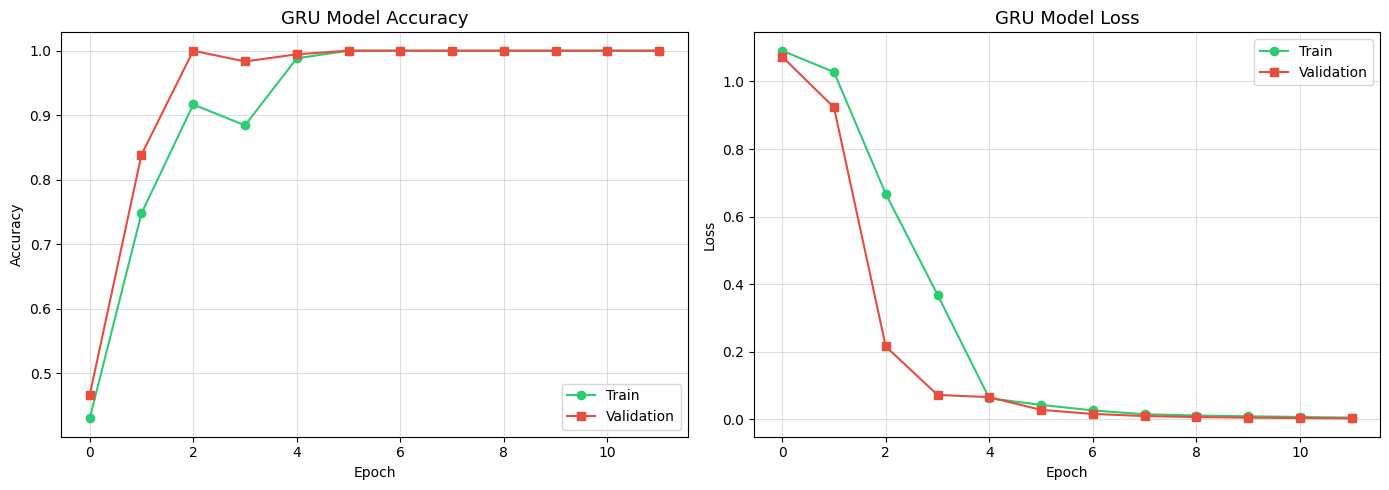

GRU training curves saved!


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],
             label='Train', marker='o', color='#2ecc71')
axes[0].plot(history.history['val_accuracy'],
             label='Validation', marker='s', color='#e74c3c')
axes[0].set_title('GRU Model Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Loss
axes[1].plot(history.history['loss'],
             label='Train', marker='o', color='#2ecc71')
axes[1].plot(history.history['val_loss'],
             label='Validation', marker='s', color='#e74c3c')
axes[1].set_title('GRU Model Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('results/lstm_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("GRU training curves saved!")

In [50]:
y_pred_gru = np.argmax(
    gru_model.predict(X_test_pad, verbose=0), axis=1
)

sample_df = pd.DataFrame({
    'original_text' : X_test.values[:10],
    'actual_label'  : le.inverse_transform(y_test.values[:10]),
    'predicted_label': le.inverse_transform(y_pred_gru[:10])
})

print("Sample Predictions:")
display(sample_df)

sample_df.to_csv('results/sample_predictions.txt', index=False, sep='\t')
print("\nSample predictions saved!")

Sample Predictions:


,original_text,actual_label,predicted_label
0,can you share the status of my router request ...,neutral,neutral
1,the refund process was fast and convenient,positive,positive
2,i would like to know more about the available ...,neutral,neutral
3,i need information about the payment process m...,neutral,neutral
4,please provide the steps to activate analytics,neutral,neutral
5,please tell me how to update my account details,neutral,neutral
6,the delivery was smooth and the product qualit...,positive,positive
7,the response from the team was helpful and pro...,positive,positive
8,please tell me how to update my account details,neutral,neutral
9,the app experience is smooth and reliable,positive,positive



Sample predictions saved!


In [51]:
reflection = """
=== Attention and Transformer Reflection ===

1. Why RNNs struggle with long-term dependencies:
   RNNs process one token at a time and pass a single hidden
   state forward. Over long sequences, early token information
   gets diluted — this is called the vanishing gradient problem.
   The model effectively forgets what it saw at the start.

2. How LSTMs help with memory:
   LSTMs introduce three gates — input, forget, and output —
   that control what information to store, discard, or pass on.
   A separate cell state acts as long-term memory alongside
   the hidden state, preserving important context across steps.

3. What attention solves in sequence-to-sequence tasks:
   Instead of compressing the entire input into one vector,
   attention lets the model look at all input tokens at once
   and assign importance weights to each. This removes the
   information bottleneck and improves handling of long inputs.

4. Why Transformers matter in modern NLP and Generative AI:
   Transformers replace recurrence entirely with self-attention,
   allowing all tokens to be processed in parallel. This makes
   training much faster and scalable. Models like BERT, GPT-4,
   and LLaMA are all transformer-based and form the backbone
   of all modern NLP and generative AI systems today.
"""

print(reflection)

with open('results/reflection_notes.txt', 'w') as f:
    f.write(reflection)
print("Reflection saved!")


=== Attention and Transformer Reflection ===

1. Why RNNs struggle with long-term dependencies:
   RNNs process one token at a time and pass a single hidden
   state forward. Over long sequences, early token information
   gets diluted — this is called the vanishing gradient problem.
   The model effectively forgets what it saw at the start.

2. How LSTMs help with memory:
   LSTMs introduce three gates — input, forget, and output —
   that control what information to store, discard, or pass on.
   A separate cell state acts as long-term memory alongside
   the hidden state, preserving important context across steps.

3. What attention solves in sequence-to-sequence tasks:
   Instead of compressing the entire input into one vector,
   attention lets the model look at all input tokens at once
   and assign importance weights to each. This removes the
   information bottleneck and improves handling of long inputs.

4. Why Transformers matter in modern NLP and Generative AI:
   Transform

In [52]:
from google.colab import files

files.download('results/eda_plots.png')
files.download('results/model_evaluation.png')
files.download('results/lstm_curves.png')
files.download('results/sample_predictions.txt')
files.download('results/reflection_notes.txt')

print("\nNotebook bhi download karo:")
print("File → Download → Download .ipynb")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Notebook bhi download karo:
File → Download → Download .ipynb
